In [25]:
unmixed_ds = xr.load_dataset("data/unmixed/min23_CorrGamma/unmixed_by_min23_CorrGamma_5_5_1_buffer2_11x11.nc")
unmixed_ds

<xarray.Dataset>
Dimensions:                        (sample: 120, wave_number: 1015)
Coordinates:
  * sample                         (sample) int64 0 1 2 3 4 ... 116 117 118 119
  * wave_number                    (wave_number) float32 1.278e+03 ... 2.82e+03
Data variables:
    spectra                        (sample, wave_number) float32 0.1916 ... 0...
    masked_spectra                 (sample, wave_number) float32 -1.0 ... -1.0
    mask                           (sample, wave_number) bool False ... False
    predicted_spectra              (sample, wave_number) float32 0.171 ... 0.137
    predicted_difference           (sample, wave_number) float32 0.02058 ... ...
    filtered_spectra               (sample, wave_number) float32 0.1905 ... 0...
    filtered_predicted_difference  (sample, wave_number) float32 0.02002 ... ...

In [124]:
import numpy as np
import xarray as xr
import scipy.signal as signal
import scipy.optimize as opt
import matplotlib.pyplot as plt
from scipy.special import wofz
import pandas as pd
from scipy.signal import convolve
from scipy.signal import medfilt as mdf
from scipy.signal import savgol_filter as sgf
from scipy.interpolate import interp1d
import os
import time 
from scipy import signal as sg

def gs(x, a, x0, s):
    """ Gaussian function """
    return a * np.exp(-(x - x0)**2 / (2 * s**2))

def gauss(x, y0, a, x0, s):
    """ Gaussian function with baseline y0 """
    return y0 + a * np.exp(-(x - x0)**2 / (2 * s**2))

def lor(x, y0, x0, gamma):
    """ Lorentzian function """
    return y0 + (1 / np.pi) * (gamma / ((x - x0)**2 + gamma**2))

def pseudo_voigt(x, y0, a, x0, gamma, sigma, eta):
    """ Pseudo-Voigt profile as a combination of Lorentzian and Gaussian """
    v = eta * lor(x, 1, x0, gamma) + (1 - eta) * gs(x, 1, x0, sigma)
    return y0 + a * v

def voigt_width(eta, lw, gw):
    """Calculate the Voigt width from Lorentzian and Gaussian widths"""
    fwhm_L = eta * lw
    fwhm_G = (1 - eta) * 2 * gw * np.sqrt(2 * np.log(2))
    vw = 0.5346 * fwhm_L + np.sqrt(0.2166 * fwhm_L**2 + fwhm_G**2)
    return vw

def normalize(arr, mode='unity'):
    """Normalize the array to a specific mode."""
    if mode == 'unity':
        return arr / np.max(arr)
    return arr

def detect_peaks(spectrum, num_peaks):
    """Find the N most prominent peaks in the spectrum."""
    spectrum = (spectrum - np.min(spectrum)) / (np.max(spectrum) - np.min(spectrum))  # Normalize
    peaks, properties = signal.find_peaks(spectrum, prominence=0.01, width=2)
    if len(peaks) < num_peaks:
        return peaks
    sorted_peaks = peaks[np.argsort(properties['prominences'])][-num_peaks:]
    return sorted_peaks

def fit_peaks(x, y, peak_positions, window_size=5):
    """ Fit peaks in a specified window around each detected peak """
    fitted_params = []
    fit_y = np.zeros_like(y)
    individual_fits = []
    
    for peak in peak_positions:
        # Define window around peak (e.g., ±5 points)
        window_start = max(0, peak - window_size)
        window_end = min(len(x), peak + window_size + 1)
        
        # Extract the windowed spectrum around the peak
        x_window = x[window_start:window_end]
        y_window = y[window_start:window_end]
        
        # Initial guesses for fitting parameters based on the window
        amp_guess = np.max(y_window)  # Maximum value in the window as amplitude guess
        center_guess = x[peak]  # The peak position from the detected peak
        sigma_guess = 1.0  # Initial guess for sigma (Gaussian width)
        gamma_guess = 1.0  # Initial guess for gamma (Lorentzian width)
        eta_guess = 0.5  # Initial guess for eta (mixture factor)
        
        p0 = [0, amp_guess, center_guess, gamma_guess, sigma_guess, eta_guess] # y0, a, x0, sigma, gamma, eta
        bounds = ([-1, 0, x[peak] - 3, 0.1, 0.1, 0], [np.inf, np.inf, x[peak] + 3, 20, 20, 1])  # Adjust bounds
        
        try:
            popt, _ = opt.curve_fit(pseudo_voigt, x_window, y_window, p0=p0, bounds=bounds, maxfev=50000)
            fitted_params.append(popt)
            peak_fit = pseudo_voigt(x_window, *popt)
            fit_y[window_start:window_end] += peak_fit
            individual_fits.append(peak_fit)
        except RuntimeError:
            continue
    
    return fitted_params, fit_y, individual_fits

def optimize_window_size(x, y, peak_positions, window_size_range=(3, 15)):
    """ Optimize the window size by minimizing the residuals """
    def residuals(window_size):
        """ Compute residuals for a given window size """
        window_size = int(window_size)
        fitted_params, fit_y, _ = fit_peaks(x, y, peak_positions, window_size)
        return np.sum((y - fit_y) ** 2)  # Sum of squared residuals
    
    # Minimize residuals over the window size range
    result = opt.minimize(residuals, x0=[(window_size_range[0] + window_size_range[1]) / 2], bounds=[window_size_range])
    
    # Return the optimized window size
    return int(result.x[0])

def process_spectra(ds, num_peaks, plot_sample, window_size_range=(3, 15)):
    """Process all spectra but plot only one specific sample."""
    results = []
    
    for i in range(ds.dims['sample']):
        x = ds.wave_number.values
        y = ds.filtered_predicted_difference[i].values
        y = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalize spectrum
        
        # Peak detection
        peak_positions = detect_peaks(y, num_peaks)
        
        # Optimize window size
        optimal_window_size = optimize_window_size(x, y, peak_positions, window_size_range)
        
        # Peak fitting with optimized window size
        fitted_params, fit_y, individual_fits = fit_peaks(x, y, peak_positions, optimal_window_size)
        residuals = y - fit_y
        
        results.append({'sample': i, 'fitted_params': fitted_params, 'residuals': residuals, 'window_size': optimal_window_size})
        
        if i == plot_sample:
            # Plot results for the specified sample
            plt.figure(figsize=(10, 8))
            plt.subplot(2, 1, 1)
            plt.plot(x, y, label='Normalized Spectrum', alpha=0.5)

            # Plot each peak fit with its corresponding windowed x values
            for peak_fit, params, peak, x_window in zip(individual_fits, fitted_params, peak_positions, [x[peak - optimal_window_size:peak + optimal_window_size + 1] for peak in peak_positions]):
                peak_center = params[2]  # x0 (center) of the pseudo-Voigt fit
                plt.plot(x_window, peak_fit, linestyle='dotted', label=f'Peak at {peak_center:.1f}')  # Center (X) in the legend

            # Plot the sum of all fitted peaks
            plt.plot(x, fit_y, label='Fitted Peaks Sum', linestyle='dashdot')

            # Scatter plot for the detected peaks
            plt.scatter(x[peak_positions], y[peak_positions], color='red', label='Detected Peaks')

            # Set plot labels and title
            plt.legend()
            plt.xlabel('Wave Number')
            plt.ylabel('Normalized Intensity')
            plt.title(f'Sample {plot_sample} with Optimized Window Size {optimal_window_size}')

            # Plot residuals
            plt.subplot(2, 1, 2)
            plt.plot(x, residuals, label='Residuals', color='black')
            plt.axhline(0, linestyle='dashed', color='gray')
            plt.xlabel('Wave Number')
            plt.ylabel('Residual Intensity')
            plt.legend()

            plt.tight_layout()
            plt.show()

    return results


/tmp/ipykernel_1735417/2569893393.py:95: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  window_size = int(window_size)


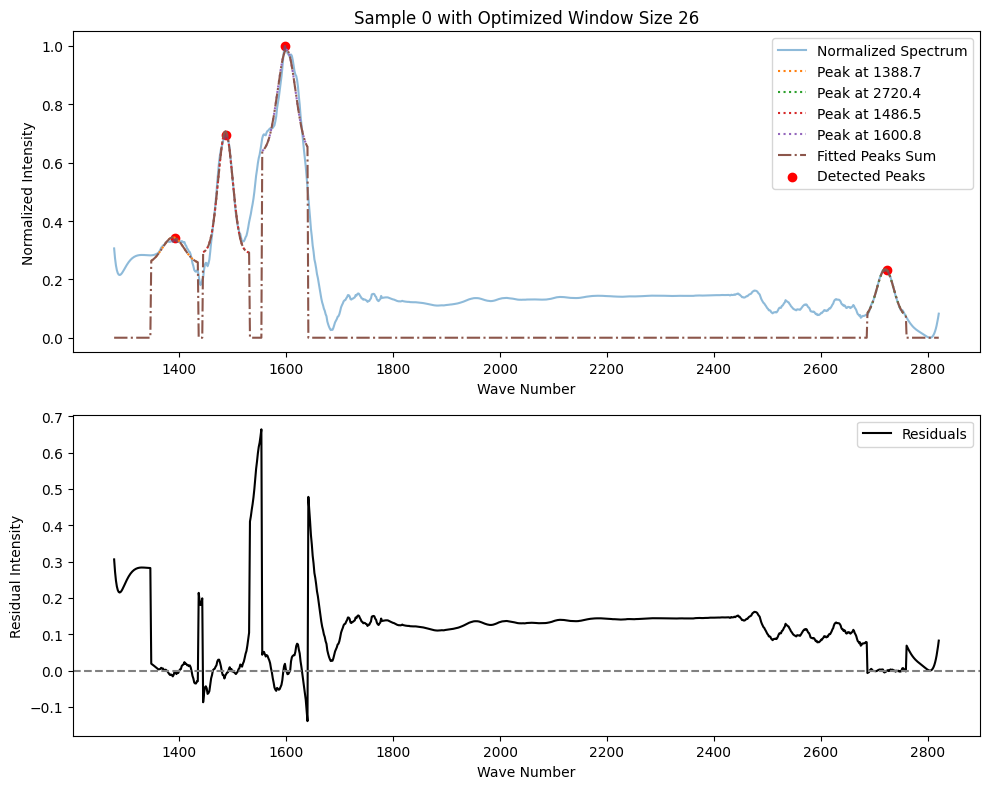

KeyboardInterrupt: 

In [127]:
results = process_spectra(unmixed_ds, num_peaks=4, plot_sample=0, window_size_range=(3, 50))
results